In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv")
df.shape

(1000, 12)

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


In [5]:
df.describe()

,student_id,study_time_hours,attendance_percent,sleep_hours,previous_grade,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,3.570700,85.092300,6.799500,69.740900,83.543500
std,288.819436,1.478559,9.270685,1.203527,12.613425,10.341333
min,1.000000,0.500000,54.800000,3.200000,31.300000,46.800000
25%,250.750000,2.600000,78.800000,5.900000,61.000000,76.075000
50%,500.500000,3.600000,85.200000,6.800000,69.600000,83.800000
75%,750.250000,4.500000,91.900000,7.600000,78.400000,91.525000
max,1000.000000,8.100000,100.000000,10.000000,100.000000,100.000000


Key Insights:
* Study Time: Varies from a minimum of 0.5 hours (30 minutes) to a maximum of 8.1 hours.
* Attendance: Ranges from 54.8% to a perfect 100%.
* Sleep: Students get between 3.2 and 10 hours of sleep.
* Score Floor: The lowest score rose significantly, moving from 31.3% in previous grades to 46.8% on the final exam.
* Score Ceiling: The maximum score achieved remained at 100% for both previous grades and the final exam.
* Average Performance: Class averages saw a noticeable upward shift, increasing from roughly 69.7% to 83.5%.

#### Incase of NA values of parental education, "Unknown" is used.

In [6]:
df['parental_education'] = df['parental_education'].fillna("Unknown")

Identifying categorical columns and using label encoder 

In [7]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gender',
 'parental_education',
 'internet_access',
 'extracurricular_activities',
 'part_time_job',
 'final_grade']

In [8]:
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

### EDA

#### 1. Grade Distribution

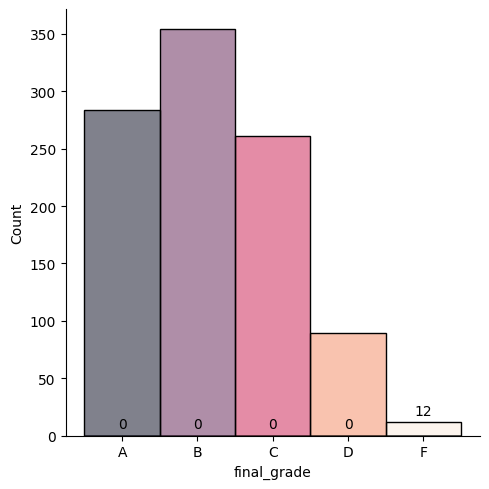

In [9]:
g = sns.displot(df,x='final_grade',binwidth=1,discrete=True,palette='rocket',hue='final_grade', legend=False)
g.set(xticks=[0, 1, 2, 3, 4], xticklabels=['A', 'B', 'C', 'D', 'F'])
for ax in g.axes.flat:
    ax.bar_label(ax.containers[0], padding=3)
plt.show()

#### 2. grade vs attendence

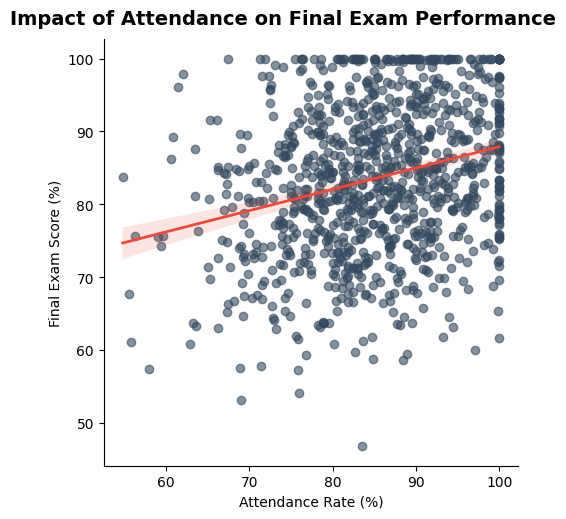

In [10]:
g = sns.lmplot(data=df, x="attendance_percent", y="final_exam_score",
              scatter_kws={'alpha': 0.6, 'color': '#34495e'},  # Softens the points to handle overlap
            line_kws={'color': '#e74c3c', 'linewidth': 2},
              )
g.set_axis_labels("Attendance Rate (%)", "Final Exam Score (%)")
g.fig.suptitle("Impact of Attendance on Final Exam Performance", y=1.03, fontsize=14, fontweight='bold')

plt.show()

1. Stronger Positive Correlation
    * What to infer: Study time is an incredibly strong, direct driver of exam performance. Every additional hour spent studying yields a highly predictable upward shift in expected grade outcomes.
    * How to see it: The red regression line slopes upward sharply. The angle of the slope is steeper than the attendance plot, and the shaded confidence interval remains tightly bound around the line across the entire spectrum.
   
2. A Hard Performance Floor (Risk Elimination)
    * What to infer: While studying less introduces high volatility (you might get lucky or fail completely), studying more completely eliminates the risk of failing.
    * How to see it: Look at the upward boundary of the lowest data points as you move right along the x-axis:
        * Below 2 hours of study time, the floor is completely unprotected—scores drop as low as 47%.
        * By 4 hours, the absolute worst-performing outlier still scores close to 60%.Beyond 6 hours, the performance floor completely rises above 80%.

3. The 100% Score Ceiling (Diminishing Returns)
    * What to infer: There is a threshold where additional studying reaches a maximum performance cap. Past roughly 5 to 6 hours of studying, scores maximize out, and the main benefit shifts from "raising your score" to "guaranteeing a perfect grade."
    * How to see it: Look at the thick, solid horizontal line of overlapping dark dots saturated perfectly at the 100% mark on the y-axis. This cluster begins forming around 3.5 hours, but by 7 to 8 hours, every single data point is pinned directly to the 100% ceiling.

4. High Variance Among Low-Study Students
    * What to infer: Minimal studying does not guarantee failure, but it introduces extreme unpredictability. Students studying under 2 hours rely heavily on other variables (like high classroom attendance or prior knowledge) to pass.
    * How to see it: Look at the vertical column of dots between 0.5 and 2 hours of study time. The data points stretch completely out into a massive vertical column spanning from 47% all the way up to 95%.

#### 3. Study Time vs Performance

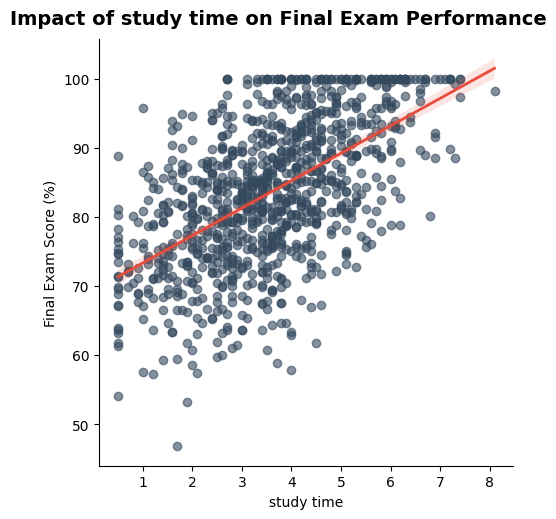

In [11]:
g = sns.lmplot(data=df, x="study_time_hours", y="final_exam_score",
              scatter_kws={'alpha': 0.6, 'color': '#34495e'},  # Softens the points to handle overlap
            line_kws={'color': '#e74c3c', 'linewidth': 2},
              )
g.set_axis_labels("study time", "Final Exam Score (%)")
g.fig.suptitle("Impact of study time on Final Exam Performance", y=1.03, fontsize=14, fontweight='bold')

plt.show()

1. Vertical Axis Mean (Final Exam Score)
   * The Overall Mean is 83.5%
   * If you look at the y-axis, the heavy center mass of the data points and the red regression line cross right through the 83.5% mark when study time is around 3.5 to 4 hours.
2.  Horizontal Axis Mean (Study Time)
       * The Overall Mean is roughly 3.4 to 3.8 hours
    * Looking along the x-axis, the densest column of overlapping dark clusters is concentrated right between the 3 and 4 hour marks.

#### 4. Sleep Distribution by Grade

/tmp/ipykernel_16/1446842219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


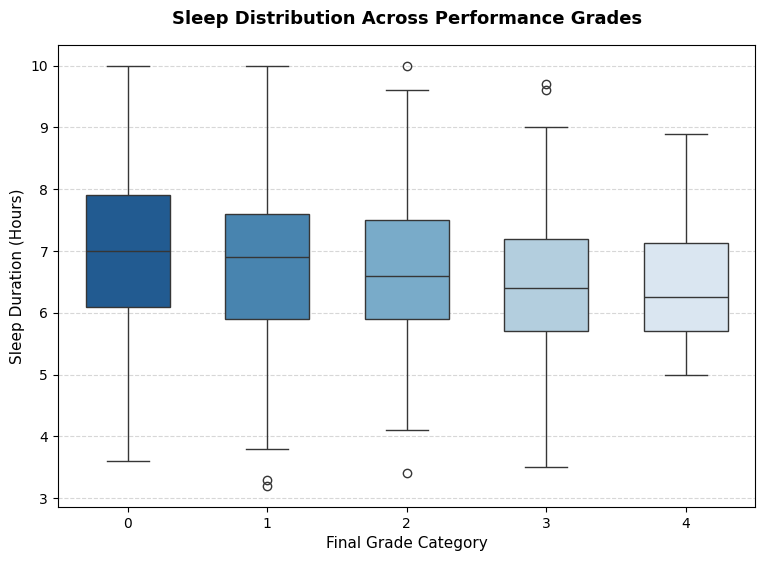

In [12]:
plt.figure(figsize=(9, 6))
ax = sns.boxplot(
    data=df,
    x='final_grade',
    y='sleep_hours',
    palette='Blues_r',
    width=0.6
)

# Style adjustments
ax.set_title("Sleep Distribution Across Performance Grades", fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Final Grade Category", fontsize=11)
ax.set_ylabel("Sleep Duration (Hours)", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)

* Grade 0 (A): The median line is exactly at 7.0 hours. Because the box is slightly stretched toward the top, the mean will be slightly higher, around 7.05 - 7.1 hours.
* Grade 1 (B): The median is at 6.9 hours. The mean will sit right around 6.8 hours due to the low-side outliers pulling it down.
* Grade 2 (C): The median is at 6.6 hours. The mean will be close to 6.6 hours as the distribution looks relatively balanced.
* Grade 3 (D): The median is at 6.4 hours. The mean will be slightly higher, around 6.45 hours, because of the high-side outliers.
* Grade 4 (F): The median is at 6.25 hours. The mean will be around 6.3 hours since the top whisker extends a bit further.

#### 4. Part-time Job vs At-Risk Rate

In [13]:
df['at_risk'] = df['final_grade'].isin([3,4]).astype('int') 
at_risk_rates = df.groupby('part_time_job')['at_risk'].mean() *100

In [14]:
at_risk_rates

part_time_job
0     6.725146
1    17.405063
Name: at_risk, dtype: float64

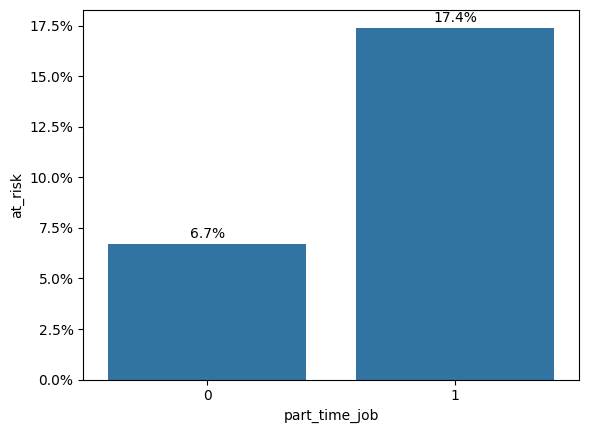

In [15]:
ax = sns.barplot(data=df,
                x='part_time_job',
                y= df['at_risk']*100,
                errorbar=None
                )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(100.0))

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=2)

plt.show()

* No Part-Time Job (0): The mean of at_risk is 0.067 (or 6.7%).
* Has Part-Time Job (1): The mean of at_risk is 0.174 (or 17.4%).